In [1]:
import pandas as pd

df = pd.read_csv('../dataset/21137.csv', low_memory=False)

df_long = df.T.reset_index()
df_long.columns = ['Week', 'Quantity']
dates = pd.date_range(start='2011-01-01', periods=len(df_long), freq='W')
df_long['Date'] = dates
df_timeseries = df_long.set_index('Date')[['Quantity']]
df_timeseries.index.freq = 'W'

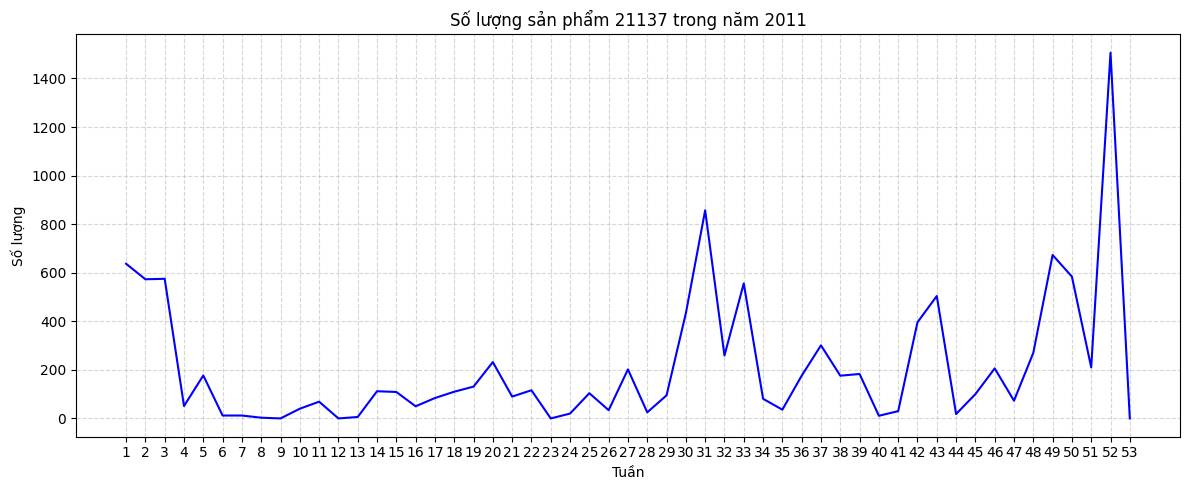

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df_timeseries.index, df_timeseries['Quantity'], color='blue')
week_numbers = range(1, len(df_long) + 1)
plt.xticks(df_timeseries.index, week_numbers)

plt.title('Số lượng sản phẩm 21137 trong năm 2011')
plt.xlabel('Tuần')
plt.ylabel('Số lượng')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

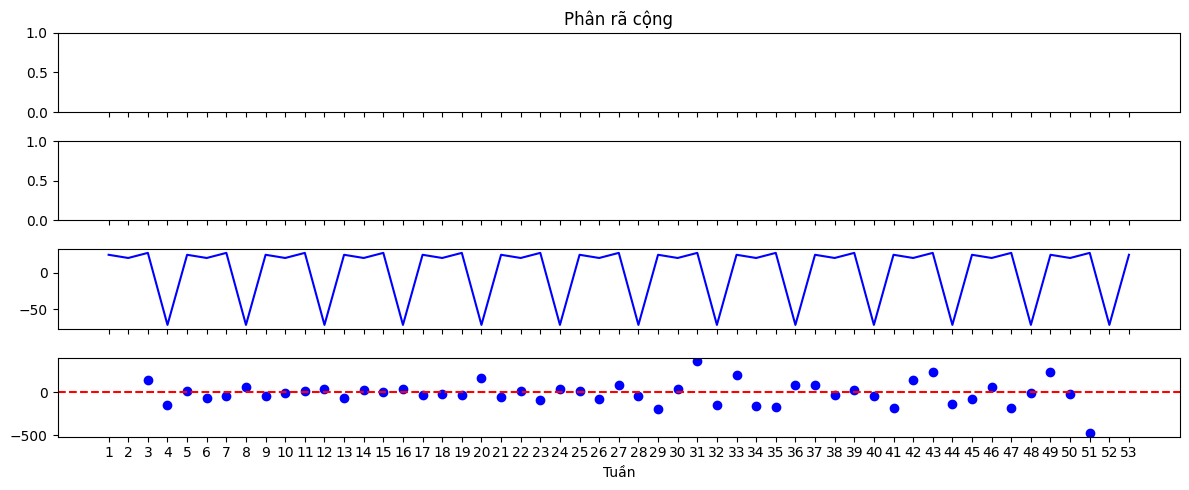

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_add = seasonal_decompose(df_timeseries['Quantity'], model='additive', period=4)
fig, axes = plt.subplots(4, 1, figsize=(12, 5), sharex=True)

# axes[0].plot(df_timeseries.index, result_add.observed, color='blue')
axes[0].set_title('Phân rã cộng')

# axes[1].plot(df_timeseries.index, result_add.trend, color='blue')
axes[2].plot(df_timeseries.index, result_add.seasonal, color='blue')
axes[3].scatter(df_timeseries.index, result_add.resid, color='blue')
axes[3].axhline(0, color='red', linestyle='--')

week_numbers = range(1, len(df_long) + 1)
plt.xticks(df_timeseries.index, week_numbers, rotation=0)
plt.xlabel('Tuần')
plt.tight_layout()
plt.show()

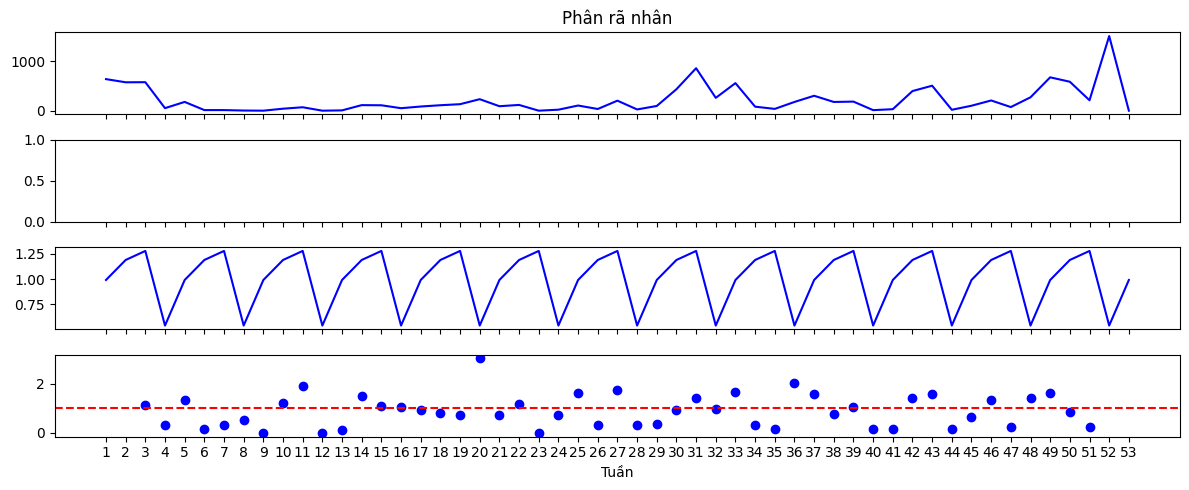

In [31]:
result_mul = seasonal_decompose(df_timeseries['Quantity'] + 0.001, model='multiplicative', period=4)
fig, axes = plt.subplots(4, 1, figsize=(12, 5), sharex=True)

axes[0].plot(df_timeseries.index, result_mul.observed, color='blue')
axes[0].set_title('Phân rã nhân')

# axes[1].plot(df_timeseries.index, result_mul.trend, color='blue')
axes[2].plot(df_timeseries.index, result_mul.seasonal, color='blue')
axes[3].scatter(df_timeseries.index, result_mul.resid, color='blue')
axes[3].axhline(1, color='red', linestyle='--')

week_numbers = range(1, len(df_timeseries) + 1)
plt.xticks(df_timeseries.index, week_numbers, rotation=0)
plt.xlabel('Tuần')
plt.tight_layout()
plt.show()

In [32]:
import numpy as np

quantity_values = df_timeseries['Quantity'].values
chunks = np.array_split(quantity_values, 4)
stats_data = []

for i, chunk in enumerate(chunks):
    stats_data.append({
        'Giai đoạn': f'Quý {i+1}',
        'Trung bình': round(chunk.mean(), 2),
        'Phương sai': round(chunk.var(), 2),
        'Var/Mean^2': round(chunk.var(), 2) / (round(chunk.mean(), 2))**2 if round(chunk.mean(), 2) != 0 else np.nan
    })

print(pd.DataFrame(stats_data))

  Giai đoạn  Trung bình  Phương sai  Var/Mean^2
0     Quý 1      161.93    53628.49    2.045224
1     Quý 2       98.62     4063.78    0.417831
2     Quý 3      245.31    55349.14    0.919772
3     Quý 4      351.54   157100.86    1.271244
